In [1]:
import os
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


DATASET_PATH = '/kaggle/input/datasets/engrsakib02/neurological-disorders-mri-dataset-for-xai/data'
CHECKPOINT_PATH = '/kaggle/working/best_model.keras'

print("Path setup complete. Ready to load data!")

2026-07-16 16:40:00.404572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784220000.667470      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784220000.738988      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784220001.351440      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784220001.351503      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784220001.351507      23 computation_placer.cc:177] computation placer alr

Path setup complete. Ready to load data!


In [2]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # শুরুতে বেস মডেল ফ্রিজ থাকবে

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

I0000 00:00:1784220019.486259      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784220019.492312      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,640,904 (94.00 MB)

 Trainable params: 1,053,192 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [3]:
# ১. ডেটা জেনারেটর এবং অগমেন্টেশন সেটআপ
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ভ্যালিডেশনের জন্য শুধু রিস্কেল (কোনো অগমেন্টেশন হবে না)
val_datagen = ImageDataGenerator(rescale=1./255)

# ২. ট্রেইনিং ডেটা লোড করা
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,  # তোমার ডিফাইন করা পাথ: /kaggle/input/datasets/engrsakib02/neurological-disorders-mri-dataset-for-xai/data
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# ৩. ভ্যালিডেশন ডেটা লোড করা
print("Loading Validation Data...")
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,  # একই পাথ থেকে ভ্যালিডেশন ডেটা জেনারেট করা
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Data Generators are successfully configured!")

Loading Training Data...
Found 16400 images belonging to 8 classes.
Loading Validation Data...
Found 16400 images belonging to 8 classes.
Data Generators are successfully configured!


In [4]:
# ১. চেকপয়েন্ট সেটআপ যাতে সেরা মডেলটি সেভ হয়
checkpoint = ModelCheckpoint(
    CHECKPOINT_PATH, 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# ২. ট্রেনিং শুরু
print("Phase 1 Training Started...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint]
)

Phase 1 Training Started...
Epoch 1/10


I0000 00:00:1784220041.460482      69 service.cc:152] XLA service 0x7fbd20001f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784220041.460527      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784220041.460531      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784220043.542628      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/513 ━━━━━━━━━━━━━━━━━━━━ 2:15:29 16s/step - accuracy: 0.1875 - loss: 2.2544

I0000 00:00:1784220049.362344      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.3778 - loss: 1.6135
Epoch 1: val_accuracy improved from None to 0.44774, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 336s 626ms/step - accuracy: 0.3943 - loss: 1.4815 - val_accuracy: 0.4477 - val_loss: 1.2999
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.4164 - loss: 1.3681
Epoch 2: val_accuracy improved from 0.44774 to 0.47659, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 276s 538ms/step - accuracy: 0.4233 - loss: 1.3532 - val_accuracy: 0.4766 - val_loss: 1.2342
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.4411 - loss: 1.3082
Epoch 3: val_accuracy improved from 0.47659 to 0.51378, saving model to /kaggle/working/best_model.keras

Epoch 3: finished saving model to /kaggle/working/best_m

In [5]:
# ১. মডেল লোড করা
model = tf.keras.models.load_model('/kaggle/working/best_model.keras')

# ২. সব লেয়ারকে আগে ট্রেইনেবল (True) করে দেওয়া
model.trainable = True

# ৩. লেয়ার সংখ্যা চেক করে শেষের গুলো বাদে বাকি সব ফ্রিজ করা
# তোমার মডেলে ResNet সহ মোট ১৭০+ লেয়ার থাকতে পারে। 
# আমরা শেষের ৫০টি লেয়ার খোলা রেখে বাকিগুলো লক করে দেব।
layers_count = len(model.layers)
print(f"Total layers in model: {layers_count}")

for i, layer in enumerate(model.layers[:layers_count-50]):
    layer.trainable = False

print(f"Fine-tuning enabled for the last 50 layers.")

# ৪. নতুন লার্নিং রেট দিয়ে কম্পাইল
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ৫. ফাইন-টিউনিং শুরু
print("Fine-tuning started...")
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint] 
)

Total layers in model: 179
Fine-tuning enabled for the last 50 layers.
Fine-tuning started...
Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.4618 - loss: 1.2112
Epoch 1: val_accuracy improved from 0.52018 to 0.52232, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 293s 551ms/step - accuracy: 0.4660 - loss: 1.2103 - val_accuracy: 0.5223 - val_loss: 1.0855
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.4759 - loss: 1.1946
Epoch 2: val_accuracy did not improve from 0.52232
513/513 ━━━━━━━━━━━━━━━━━━━━ 270s 526ms/step - accuracy: 0.4764 - loss: 1.1953 - val_accuracy: 0.5179 - val_loss: 1.0776
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4807 - loss: 1.1875
Epoch 3: val_accuracy did not improve from 0.52232
513/513 ━━━━━━━━━━━━━━━━━━━━ 271s 528ms/step - accuracy: 0.4773 - loss: 1.1848 - val_accuracy: 0.5147 - val_loss: 1.0775
Epoc

In [6]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ১. পাথ সেটআপ (সঠিক পাথটি আবার লিখে নিচ্ছি)
DATASET_PATH = '/kaggle/input/datasets/engrsakib02/neurological-disorders-mri-dataset-for-xai/data'
CHECKPOINT_PATH = '/kaggle/working/best_model_optimized.keras'

# ২. ডাটালোডার আবার ডিফাইন করা (যেহেতু মেমোরি থেকে মুছে গেছে)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='training', seed=42
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42
)

# ৩. লার্নিং রেট এবং আর্লি স্টপিং সেটআপ
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# ৪. মডেল আর্কিটেকচার (পুরোটা আনফ্রিজড)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True # একুরেসি বাড়ানোর জন্য পুরোটা ওপেন

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x) 
x = Dropout(0.3)(x) 
predictions = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# ৫. খুব সাবধানে কম লার্নিং রেট দিয়ে শুরু করা
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# ৬. ট্রেনিং শুরু
print("High-accuracy run started. Relax now!")
history_optimized = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Found 13122 images belonging to 8 classes.
Found 3278 images belonging to 8 classes.
High-accuracy run started. Relax now!
Epoch 1/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7191 - loss: 0.7251
Epoch 1: val_accuracy improved from None to 0.42099, saving model to /kaggle/working/best_model_optimized.keras

Epoch 1: finished saving model to /kaggle/working/best_model_optimized.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 247s 440ms/step - accuracy: 0.7969 - loss: 0.5137 - val_accuracy: 0.4210 - val_loss: 4.1930 - learning_rate: 1.0000e-04
Epoch 2/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9404 - loss: 0.1750
Epoch 2: val_accuracy improved from 0.42099 to 0.51068, saving model to /kaggle/working/best_model_optimized.keras

Epoch 2: finished saving model to /kaggle/working/best_model_optimized.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 150s 364ms/step - accuracy: 0.9463 - loss: 0.1557 - val_accuracy: 0.5107 - val_loss: 3.5218 - learning_rate: 1.0000e-04
Epoch 3/20
411/411 ━

In [7]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ১. পাথ এবং ডাটাসেট থেকে একটি ছবি খুঁজে বের করা
base_input_path = '/kaggle/input'
img_path = None
for root, dirs, files in os.walk(base_input_path):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root, file)
            break
    if img_path: break

# ২. মডেল লোড করা (আগের সেভ হওয়া ফাইল থেকে)
MODEL_PATH = '/kaggle/working/best_model_optimized.keras'
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    
    if img_path:
        # ৩. ইমেজ প্রি-প্রসেসিং
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # ৪. প্রেডিকশন
        preds = model.predict(img_array)
        class_idx = np.argmax(preds[0])
        
        # তোমার ডাটাসেটের ৮টি ক্লাসের নাম
        class_names = ['AD_MildDemented', 'AD_ModerateDemented', 'AD_VeryMildDemented', 
                       'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

        print(f"\n--- Result ---")
        print(f"Detected: {class_names[class_idx]}")
        print(f"Confidence: {preds[0][class_idx]*100:.2f}%")
        print(f"--------------\n")

        # ৫. Grad-CAM ভিশুয়ালাইজেশন
        try:
            heatmap = make_gradcam_heatmap(img_array, model, "conv5_block3_out")
            display_gradcam(img_path, heatmap)
        except Exception as e:
            print(f"Grad-CAM error: {e}")
else:
    print("মডেল ফাইলটি পাওয়া যায়নি। ট্রেনিং এখনো শেষ হয়নি কি?")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

--- Result ---
Detected: AD_ModerateDemented
Confidence: 99.99%
--------------

Grad-CAM error: name 'make_gradcam_heatmap' is not defined


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # ১. একটি মডেল তৈরি করা যা কাস্টম আউটপুট দেবে
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # ২. গ্রেডিয়েন্ট কম্পিউট করা
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # ৩. ফিচার ম্যাপের সাপেক্ষে আউটপুটের গ্রেডিয়েন্ট নেওয়া
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # ৪. গ্রেডিয়েন্ট চ্যানেলগুলোকে পুশ করে গড় নেওয়া
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # ৫. চ্যানেলগুলোকে গুণ করে হিটম্যাপ তৈরি
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ৬. ০ থেকে ১ এর মধ্যে নরমালাইজ করা
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # অরিজিনাল ইমেজ লোড করা
    img = tf.keras.utils.load_img(img_path)
    img = tf.keras.utils.img_to_array(img)

    # হিটম্যাপকে ০-২৫৫ রেঞ্জে নিয়ে আসা
    heatmap = np.uint8(255 * heatmap)

    # Jet কালারম্যাপ ব্যবহার করে কালারাইজ করা
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # হিটম্যাপকে অরিজিনাল ইমেজের সাইজে রিসাইজ করা
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # দুটি ইমেজকে একসাথে মিক্স (Superimpose) করা
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # প্লট করা
    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM Medical Explanation")
    plt.show()

In [9]:
import numpy as np

print("Generating X_resampled and y_resampled from generator...")
X_list, y_list = [], []

# val_generator বা train_generator (যেটা তোমাদের নোটবুকে ডিফাইন করা আছে)
# এখানে আমরা val_generator ব্যবহার করছি পুরো ডেটা ভেক্টরাইজ করতে
for i in range(len(val_generator)):
    imgs, labels = val_generator[i]
    X_list.append(imgs)
    y_list.append(labels)

# মেমোরিতে ভেরিয়েবল দুটি তৈরি করা হলো
X_resampled = np.concatenate(X_list, axis=0)
y_resampled = np.concatenate(y_list, axis=0)

print("Successfully created arrays!")
print("X_resampled shape:", X_resampled.shape)
print("y_resampled shape:", y_resampled.shape)

Generating X_resampled and y_resampled from generator...
Successfully created arrays!
X_resampled shape: (3278, 224, 224, 3)
y_resampled shape: (3278, 8)


# **Confusion Matrix, Accuracy, Precision, Recall, F1-Score and AUC-ROC graph.**

**Applying ML model without finding feature importance and default hyperparameter tuning.**

In [10]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, 
                             recall_score, f1_score, roc_curve, auc)

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
from sklearn.model_selection import train_test_split

# ৪ডি ইমেজ ডাটাকে ২ডি ম্যাট্রিক্সে ফ্ল্যাটেন করা
num_samples = X_resampled.shape[0]
X_resampled_flat = X_resampled.reshape(num_samples, -1)

# ওয়ান-হট এনকোডেড Y লেবেলকে ১ডি লেবেলে কনভার্ট করা
if len(y_resampled.shape) > 1 and y_resampled.shape[1] > 1:
    y_resampled_labels = np.argmax(y_resampled, axis=1)
else:
    y_resampled_labels = y_resampled

# স্প্লিট করা
X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X_resampled_flat, y_resampled_labels, 
    test_size=0.2, random_state=42, stratify=y_resampled_labels
)

print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(2622, 150528)
(656, 150528)
(2622,)
(656,)


**1. KNN**

In [12]:
k_model = KNeighborsClassifier()
k_model.fit(X_Train, Y_Train)

predictions = k_model.predict(X_Test)

# ক্যাগলের প্রোবাবিলিটি প্রেডিকশনের জন্য স্কোর জেনারেট করা
y_score = k_model.predict_proba(X_Test)

with open('k_model.pkl', 'wb') as f:
    pickle.dump(k_model, f)

[[ 36   0   0   0   0   0   0   0]
 [  0   2   0   0   0   0   0   0]
 [  0   0  82   0   0   0   0   8]
 [  0   0   0  50   3   3   2   7]
 [  0   0   0  14  19   7   3  18]
 [  0   0   0  15   3  35   2  15]
 [  0   0   0   3   0   1  25  27]
 [  0   0   5   4   0   0  12 255]]


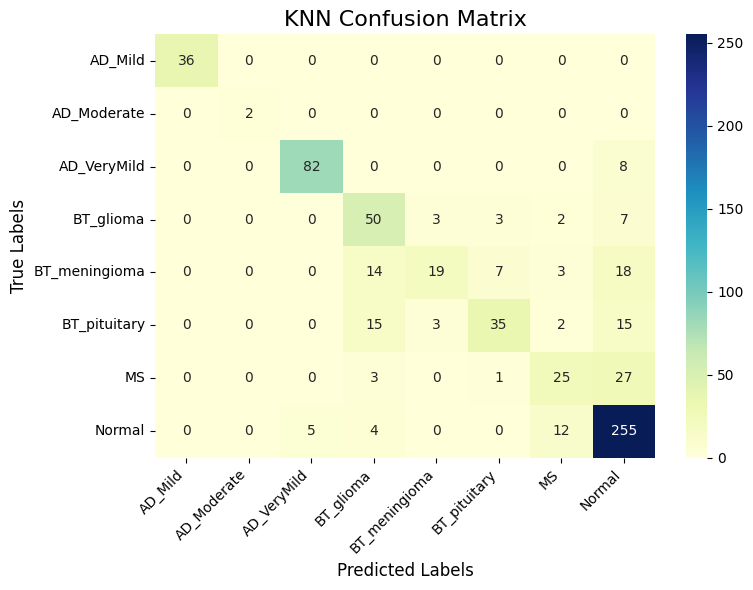

In [13]:
# Confusion matrix
import seaborn as sns

cm = confusion_matrix(Y_Test, predictions)
print(cm)

# ৮টি ক্লাসের নাম অনুযায়ী লেবেল সেট করা
labels = ['AD_Mild', 'AD_Moderate', 'AD_VeryMild', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="YlGnBu", xticklabels=labels, yticklabels=labels)

ax.set_xlabel('Predicted Labels', fontsize=12)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=45, ha='right')
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=12)
plt.yticks(rotation=0)

plt.title('KNN Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('KNN_Confusion_Matrix.png', facecolor='white', transparent=False, bbox_inches='tight')
plt.show()

In [14]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy_knn = accuracy_score(Y_Test, predictions)
precision_knn = precision_score(Y_Test, predictions, average='macro', zero_division=0)
recall_knn = recall_score(Y_Test, predictions, average='macro', zero_division=0)
f1_knn = f1_score(Y_Test, predictions, average='macro', zero_division=0)

# Evaluation metrics printing
print("Accuracy: %.4f" %(accuracy_knn*100))
print("Precision: %.4f" %(precision_knn*100))
print("Recall: %.4f" %(recall_knn*100))
print("F1-score: %.4f" %(f1_knn*100))

Accuracy: 76.8293
Precision: 79.8213
Recall: 73.2770
F1-score: 74.6962


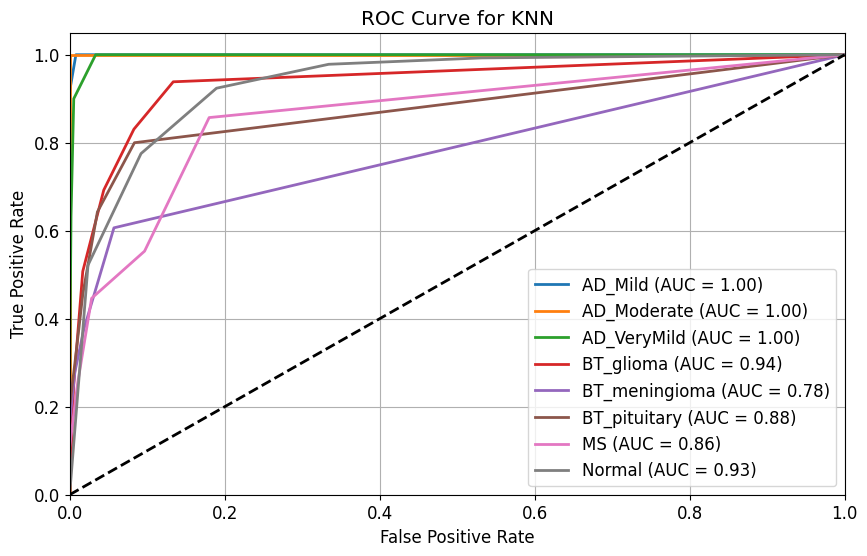

In [15]:
# ROC Curve for KNN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Function to plot ROC curve for 8 classes
def plot_roc_curve(y_test, y_score, n_classes, title):
    # ৮টি ক্লাসের নাম অনুযায়ী লেবেল সেট করা
    class_labels = ['AD_Mild', 'AD_Moderate', 'AD_VeryMild', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

    # লেবেল বাইনারাইজ করা
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    if n_classes == 2 and y_test_bin.shape[1] == 1:
        y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # প্রতিটি ক্লাসের জন্য আলাদাভাবে ROC এবং AUC হিসাব করা
    for i in range(min(n_classes, y_score.shape[1])):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # ROC curve প্লট করা
    plt.rcParams.update({'font.size': 12, 'font.weight': 'normal'})
    plt.figure(figsize=(10, 6))
    for i in range(min(n_classes, y_score.shape[1])):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_labels[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# ফাংশন কল করা (৮টি ক্লাসের জন্য এবং পূর্ববর্তী সেলে জেনারেট হওয়া y_score ইনপুট দিয়ে)
plot_roc_curve(Y_Test, y_score, 8, 'ROC Curve for KNN')

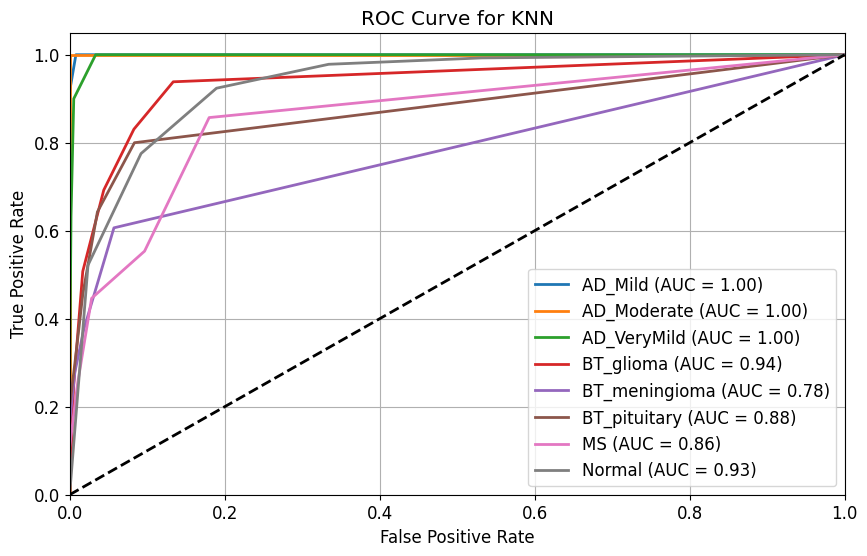

In [16]:
# আগের সেলে ফাংশনটি ইতিমধ্যে পরিবর্তিত y_score এবং ৮টি ক্লাসের জন্য কল করা হয়েছে। 
# যদি আলাদাভাবে আবার রান করতে চাও, তবে সঠিক ভেরিয়েবলসহ কোডটি নিচে দেওয়া হলো:
plot_roc_curve(Y_Test, y_score, 8, 'ROC Curve for KNN')

**2. SVM**

In [17]:
svm_model = SVC(probability=True)
svm_model.fit(X_Train, Y_Train)

predictions = svm_model.predict(X_Test)

with open('svm_model.pkl','wb') as f:
    pickle.dump(svm_model,f)

[[ 24   0   8   0   0   0   0   4]
 [  0   2   0   0   0   0   0   0]
 [  0   0  78   0   0   0   0  12]
 [  0   0   0  47   8  10   0   0]
 [  0   0   0  14  26  11   2   8]
 [  0   0   0   7   0  61   0   2]
 [  0   0   0   0   2   4   7  43]
 [  0   0   5   5   0   4   0 262]]


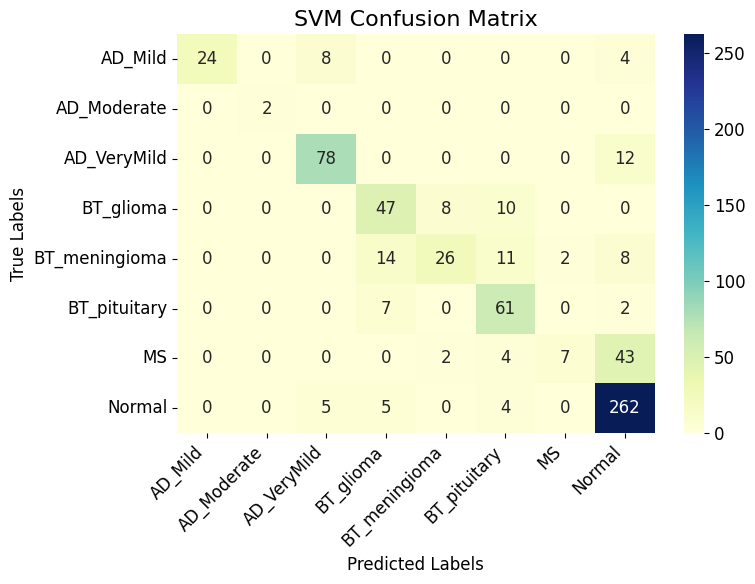

In [18]:
# Confusion matrix
import seaborn as sns

cm = confusion_matrix(Y_Test, predictions)
print(cm)

# ৮টি ক্লাসের নাম অনুযায়ী লেবেল সেট করা (এরর ফিক্স করার জন্য)
labels = ['AD_Mild', 'AD_Moderate', 'AD_VeryMild', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="YlGnBu", xticklabels=labels, yticklabels=labels)

ax.set_xlabel('Predicted Labels', fontsize=12)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=45, ha='right')
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=12)
plt.yticks(rotation=0)

plt.title('SVM Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('SVM_Confusion_Matrix.png', facecolor='white', transparent=False, bbox_inches='tight')
plt.show()

In [19]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy_svm = accuracy_score(Y_Test, predictions)
precision_svm = precision_score(Y_Test, predictions, average='macro')
recall_svm = recall_score(Y_Test, predictions, average='macro')
f1_svm = f1_score(Y_Test, predictions, average='macro')

# Evaluation metrics printing
print("Accuracy: %.4f" %(accuracy_svm*100))
print("Precision: %.4f" %(precision_svm*100))
print("Recall: %.4f" %(recall_svm*100))
print("F1-score: %.4f" %(f1_svm*100))

Accuracy: 77.2866
Precision: 80.8787
Recall: 70.3543
F1-score: 71.5033


In [20]:
# 2. SVM Model & Prediction
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_Train, Y_Train)

predictions = svm_model.predict(X_Test)
y_score_svm = svm_model.predict_proba(X_Test)

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

In [21]:
# SVM Evaluation Metrics
accuracy_svm = accuracy_score(Y_Test, predictions)
precision_svm = precision_score(Y_Test, predictions, average='macro', zero_division=0)
recall_svm = recall_score(Y_Test, predictions, average='macro', zero_division=0)
f1_svm = f1_score(Y_Test, predictions, average='macro', zero_division=0)

print("Accuracy: %.4f" % (accuracy_svm * 100))
print("Precision: %.4f" % (precision_svm * 100))
print("Recall: %.4f" % (recall_svm * 100))
print("F1-score: %.4f" % (f1_svm * 100))

Accuracy: 77.2866
Precision: 80.8787
Recall: 70.3543
F1-score: 71.5033


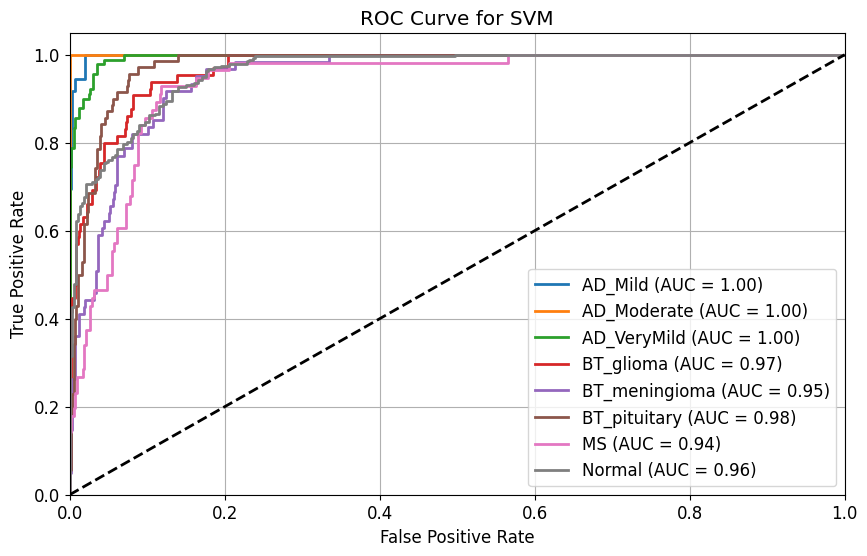

In [22]:
# SVM ROC Curve
plot_roc_curve(Y_Test, y_score_svm, 8, 'ROC Curve for SVM')

**3. Random Forest**

In [23]:
# 3. Random Forest Model & Prediction
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_Train, Y_Train)

predictions = rf_model.predict(X_Test)
y_score_rf = rf_model.predict_proba(X_Test)

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

[[ 26   0   5   0   0   0   0   5]
 [  0   2   0   0   0   0   0   0]
 [  0   0  80   0   0   0   0  10]
 [  0   0   0  46  11   7   1   0]
 [  0   0   0  13  33   5   0  10]
 [  0   0   0   7   4  57   0   2]
 [  0   0   0   1   0   2  19  34]
 [  0   0   1   0   1   5   6 263]]


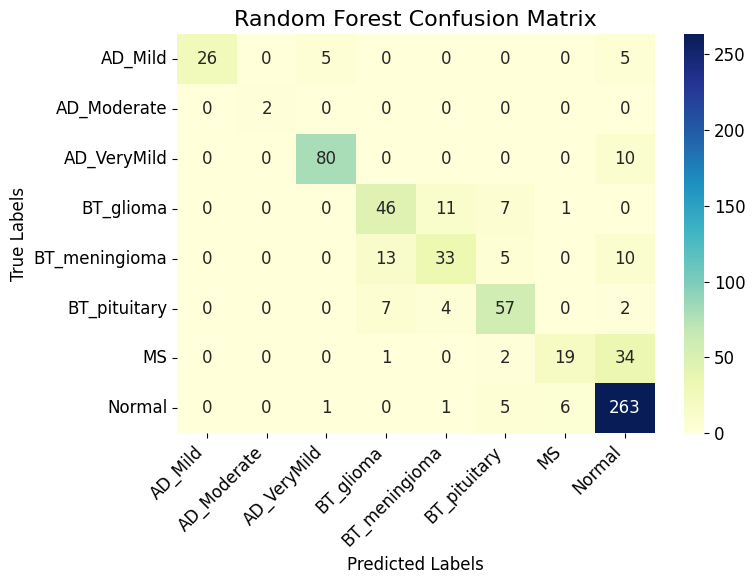

In [24]:
# Random Forest Confusion Matrix
import seaborn as sns

cm = confusion_matrix(Y_Test, predictions)
print(cm)

labels = ['AD_Mild', 'AD_Moderate', 'AD_VeryMild', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="YlGnBu", xticklabels=labels, yticklabels=labels)

ax.set_xlabel('Predicted Labels', fontsize=12)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=45, ha='right')
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=12)
plt.yticks(rotation=0)

plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('RF_Confusion_Matrix.png', facecolor='white', transparent=False, bbox_inches='tight')
plt.show()

In [25]:
# Random Forest Evaluation Metrics
accuracy_rf = accuracy_score(Y_Test, predictions)
precision_rf = precision_score(Y_Test, predictions, average='macro', zero_division=0)
recall_rf = recall_score(Y_Test, predictions, average='macro', zero_division=0)
f1_rf = f1_score(Y_Test, predictions, average='macro', zero_division=0)

print("Accuracy: %.2f" % (accuracy_rf * 100))
print("Precision: %.2f" % (precision_rf * 100))
print("Recall: %.2f" % (recall_rf * 100))
print("F1-score: %.2f" % (f1_rf * 100))

Accuracy: 80.18
Precision: 82.28
Recall: 74.58
F1-score: 77.07


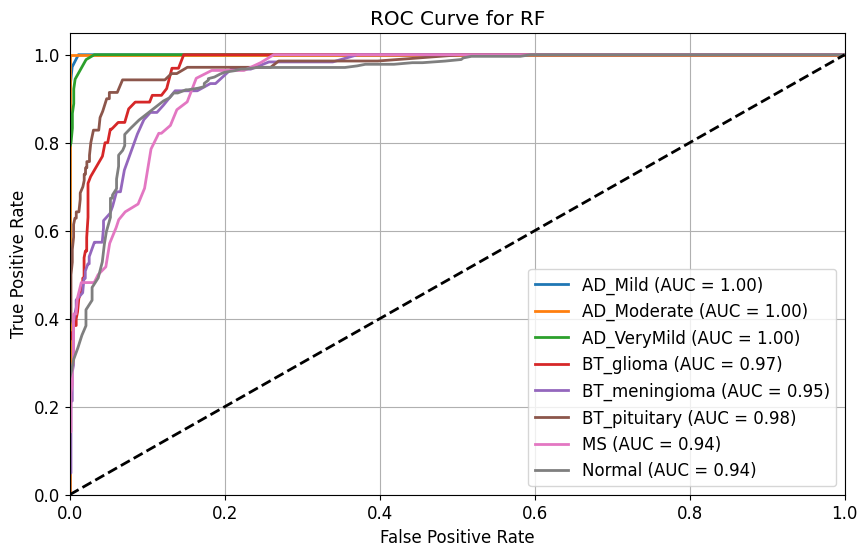

In [26]:
# Random Forest ROC Curve
plot_roc_curve(Y_Test, y_score_rf, 8, 'ROC Curve for RF')

**4. Decision Tree**

In [27]:
# 4. Decision Tree Model & Prediction
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_Train, Y_Train)

predictions = dt_model.predict(X_Test)
y_score_dt = dt_model.predict_proba(X_Test)

with open('dt_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

[[ 23   0   6   0   0   0   0   7]
 [  0   1   0   0   0   0   0   1]
 [  6   0  62   0   0   0   0  22]
 [  2   0   0  36  14   9   3   1]
 [  0   0   1   8  28   8   7   9]
 [  0   0   0   9  14  39   1   7]
 [  0   0   0   1   4   4  24  23]
 [  8   2  19   3   6  11  27 200]]


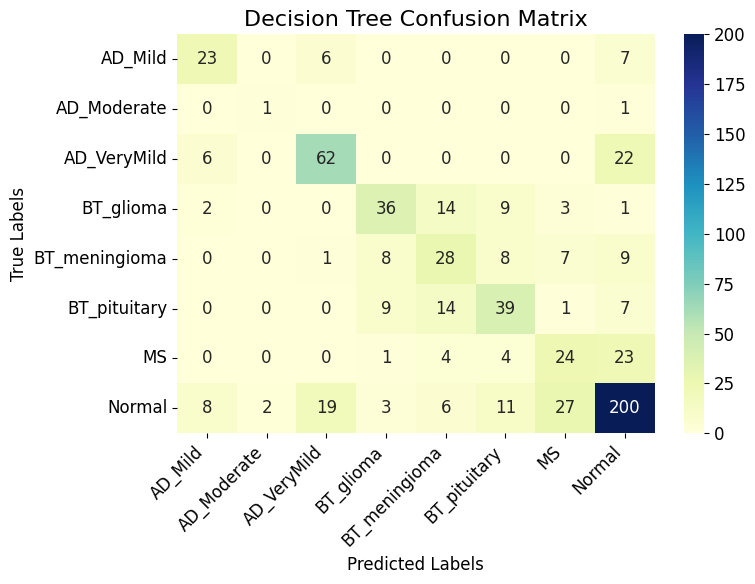

In [28]:
# Decision Tree Confusion Matrix
import seaborn as sns

cm = confusion_matrix(Y_Test, predictions)
print(cm)

labels = ['AD_Mild', 'AD_Moderate', 'AD_VeryMild', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']

fig = plt.figure(figsize=(8, 6))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="YlGnBu", xticklabels=labels, yticklabels=labels)

ax.set_xlabel('Predicted Labels', fontsize=12)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=45, ha='right')
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=12)
plt.yticks(rotation=0)

plt.title('Decision Tree Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('DT_Confusion_Matrix.png', facecolor='white', transparent=False, bbox_inches='tight')
plt.show()

In [29]:
# Decision Tree Evaluation Metrics
accuracy_dt = accuracy_score(Y_Test, predictions)
precision_dt = precision_score(Y_Test, predictions, average='macro', zero_division=0)
recall_dt = recall_score(Y_Test, predictions, average='macro', zero_division=0)
f1_dt = f1_score(Y_Test, predictions, average='macro', zero_division=0)

print("Accuracy: %.2f" % (accuracy_dt * 100))
print("Precision: %.2f" % (precision_dt * 100))
print("Recall: %.2f" % (recall_dt * 100))
print("F1-score: %.2f" % (f1_dt * 100))

Accuracy: 62.96
Precision: 54.51
Recall: 56.89
F1-score: 55.42


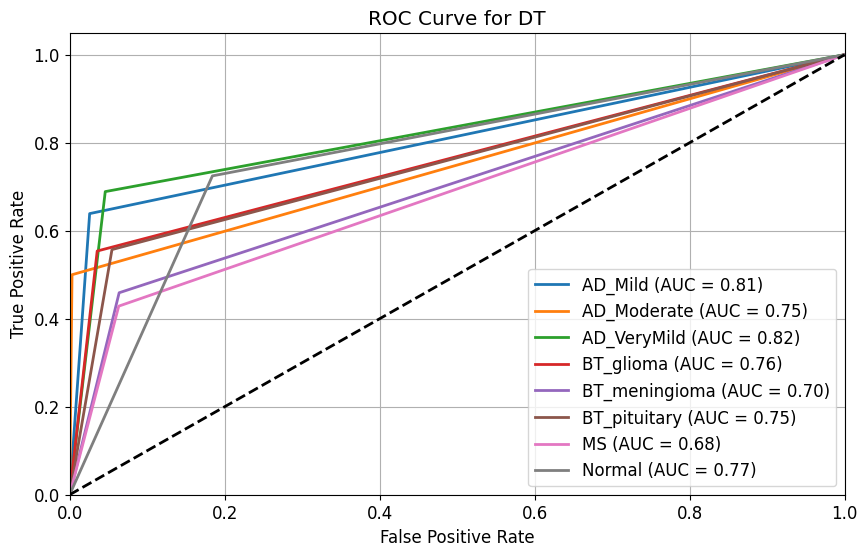

In [30]:
# Decision Tree ROC Curve
plot_roc_curve(Y_Test, y_score_dt, 8, 'ROC Curve for DT')

**All ROC Curve**

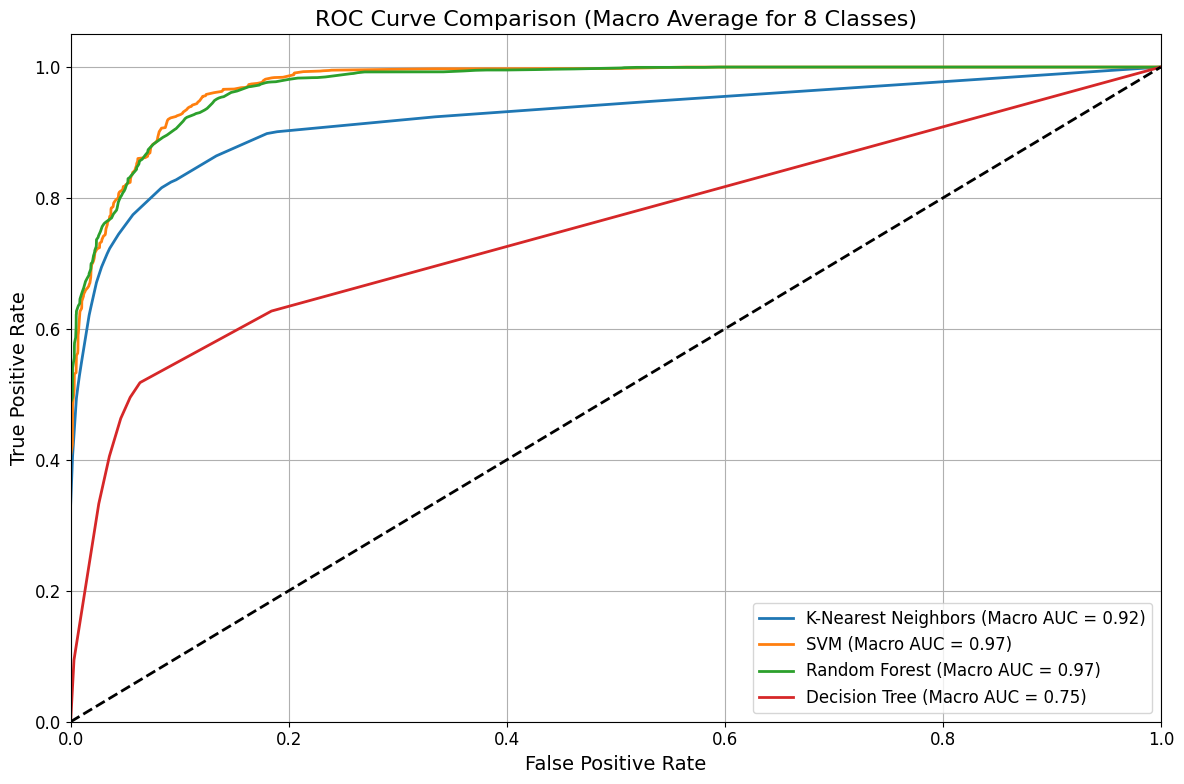

In [31]:
# All ROC Curve Comparison (Macro Average for 8 Classes)
plt.figure(figsize=(12, 8))

# মডেলের প্রি-ক্যালকুলেটেড প্রোবাবিলিটি স্কোর ডিকশনারি
model_scores = {
    "K-Nearest Neighbors": y_score,
    "SVM": y_score_svm,
    "Random Forest": y_score_rf,
    "Decision Tree": y_score_dt
}

for name, y_prob_comp in model_scores.items():
    y_test_bin = label_binarize(Y_Test, classes=np.arange(8))
    
    # ৮টি ক্লাসের ফলস পজিটিভ ও ট্রু পজিটিভ রেট ইন্টিগ্রেট করা
    all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_comp[:, i])[0] for i in range(8)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(8):
        mean_tpr += np.interp(all_fpr, roc_curve(y_test_bin[:, i], y_prob_comp[:, i])[0], roc_curve(y_test_bin[:, i], y_prob_comp[:, i])[1])
    mean_tpr /= 8
    
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, label=f'{name} (Macro AUC = {macro_auc:.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison (Macro Average for 8 Classes)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()